# Pha R - Buoc 1: Sinh kho ngu lieu (corpus)

**Muc tieu:** sinh ~27.000 cua so train/val + ~18.000 cua so test, luu ra dia de cac notebook sau nap lai ma khong phai sinh lai.

**Thoi gian uoc tinh:** vai phut (chi sinh du lieu, khong train gi).

**Output:** `data/interim/synthetic_corpus/` - corpus train/val va test rieng biet.

Xem spec day du trong [`docs/PHASE_R_GUIDE.md`](../docs/PHASE_R_GUIDE.md) muc 3.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import yaml, numpy as np
from pathlib import Path

from pqrst.data.synthetic.corpus import (generate_corpus, split_corpus_by_seed,
                                         save_corpus, load_corpus)

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
cfg = yaml.safe_load(open(BASE/'configs'/'synthetic'/'corpus.yaml', encoding='utf-8'))
cfg

{'a': 0.5,
 'b': 0.5,
 'coupling_values': [0.0, 0.2, 0.4, 0.6, 0.8],
 'noise_values': [0.3, 0.5, 1.0],
 'n_values': [10, 20, 30, 50, 100, 200],
 'n_windows_per_cell': 300,
 'base_seed': 100000,
 'val_fraction': 0.15,
 'split_seed': 7,
 'test_base_seed': 900000,
 'test_n_windows_per_cell': 200}

## 1. Sinh corpus train/validation

In [2]:
import time
start = time.time()
corpus = generate_corpus(
    coupling_values=cfg['coupling_values'],
    noise_values=cfg['noise_values'],
    n_values=cfg['n_values'],
    n_windows_per_cell=cfg['n_windows_per_cell'],
    a=cfg['a'],
    b=cfg['b'],
    base_seed=cfg['base_seed']
)
print(f'Time: {time.time()-start:.2f}s')
print(f'Tong so cua so: {len(corpus)}')
cells = set((w.config_name, w.n_samples) for w in corpus)
print(f'So o luoi: {len(cells)}')
ns = [w.n_samples for w in corpus]
from collections import Counter
print(f'Phan bo N: {Counter(ns)}')


Time: 7.00s
Tong so cua so: 27000
So o luoi: 90
Phan bo N: Counter({10: 4500, 20: 4500, 30: 4500, 50: 4500, 100: 4500, 200: 4500})


## 2. Chia train / validation (theo CUA SO, khong theo mau)

In [3]:
train_windows, val_windows = split_corpus_by_seed(corpus, val_fraction=cfg['val_fraction'], split_seed=cfg['split_seed'])
print(f'Train size: {len(train_windows)}, Val size: {len(val_windows)}')


Train size: 22950, Val size: 4050


## 3. Sinh tap TEST rieng biet

Seed hoan toan khac (`test_base_seed`). **Tap nay khong duoc dung trong bat ky quyet dinh nao o buoc train.**

In [4]:
test_corpus = generate_corpus(
    coupling_values=cfg['coupling_values'],
    noise_values=cfg['noise_values'],
    n_values=cfg['n_values'],
    n_windows_per_cell=cfg['test_n_windows_per_cell'],
    a=cfg['a'],
    b=cfg['b'],
    base_seed=cfg['test_base_seed']
)
print(f'Test size: {len(test_corpus)}')


Test size: 18000


## 4. Luu ra dia + kiem tra nap lai duoc

In [5]:
out_dir = BASE / 'data' / 'interim' / 'synthetic_corpus'
out_dir.mkdir(parents=True, exist_ok=True)
save_corpus(train_windows, str(out_dir / 'train.npz'))
save_corpus(val_windows, str(out_dir / 'val.npz'))
save_corpus(test_corpus, str(out_dir / 'test.npz'))

loaded_train = load_corpus(str(out_dir / 'train.npz'))
assert len(loaded_train) == len(train_windows)
assert np.array_equal(loaded_train[0].y_t, train_windows[0].y_t)
print('Round-trip save/load OK.')


Round-trip save/load OK.


## 5. Kiem tra chat luong corpus (sanity check)

Bang ground-truth TE theo tung muc coupling - TE phai tang don dieu theo `c`, va bang 0 khi `c=0`.

,c,noise,te_gt
0,0.0,0.3,-2.220446e-16
3600,0.2,0.3,2.556637e-02
7200,0.4,0.3,9.205251e-02
10800,0.6,0.3,1.813948e-01
14400,0.8,0.3,2.807001e-01
1200,0.0,0.5,0.000000e+00
4800,0.2,0.5,2.556637e-02
8400,0.4,0.5,9.205251e-02
12000,0.6,0.5,1.813948e-01
15600,0.8,0.5,2.807001e-01


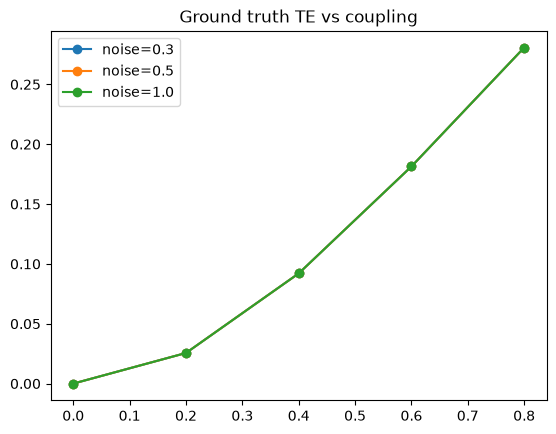

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
res = []
for w in test_corpus:
    res.append({
        'c': w.params['c'],
        'noise': w.params['noise_std'],
        'te_gt': w.te_ground_truth
    })
df = pd.DataFrame(res).drop_duplicates().sort_values(['noise', 'c'])
display(df)
for noise, g in df.groupby('noise'):
    plt.plot(g['c'], g['te_gt'], marker='o', label=f'noise={noise}')
plt.title('Ground truth TE vs coupling')
plt.legend()
plt.show()
